# 🎨 Seaborn Fundamentals
Fixed notebook: `distplot` → `histplot`, `ci` → `errorbar`, cleaned duplicate imports.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
import warnings
warnings.filterwarnings('ignore')

## 1. Available Seaborn Datasets

In [4]:
dt = sns.get_dataset_names()
dt

['anagrams',
 'anscombe',
 'attention',
 'brain_networks',
 'car_crashes',
 'diamonds',
 'dots',
 'dowjones',
 'exercise',
 'flights',
 'fmri',
 'geyser',
 'glue',
 'healthexp',
 'iris',
 'mpg',
 'penguins',
 'planets',
 'seaice',
 'taxis',
 'tips',
 'titanic']

## 2. Scatter Plot — Car Crashes Dataset

In [6]:
df = sns.load_dataset('car_crashes')
df.head()

,total,speeding,alcohol,not_distracted,no_previous,ins_premium,ins_losses,abbrev
0,18.8,7.332,5.640,18.048,15.040,784.55,145.08,AL
1,18.1,7.421,4.525,16.290,17.014,1053.48,133.93,AK
2,18.6,6.510,5.208,15.624,17.856,899.47,110.35,AZ
3,22.4,4.032,5.824,21.056,21.280,827.34,142.39,AR
4,12.0,4.200,3.360,10.920,10.680,878.41,165.63,CA


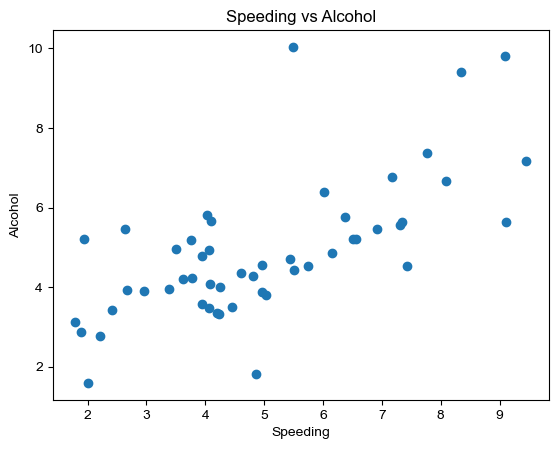

In [7]:
# Basic scatter
plt.scatter(df.speeding, df.alcohol)
sns.set()
plt.xlabel('Speeding'); plt.ylabel('Alcohol')
plt.title('Speeding vs Alcohol')
plt.show()

## 3. Seaborn Styles

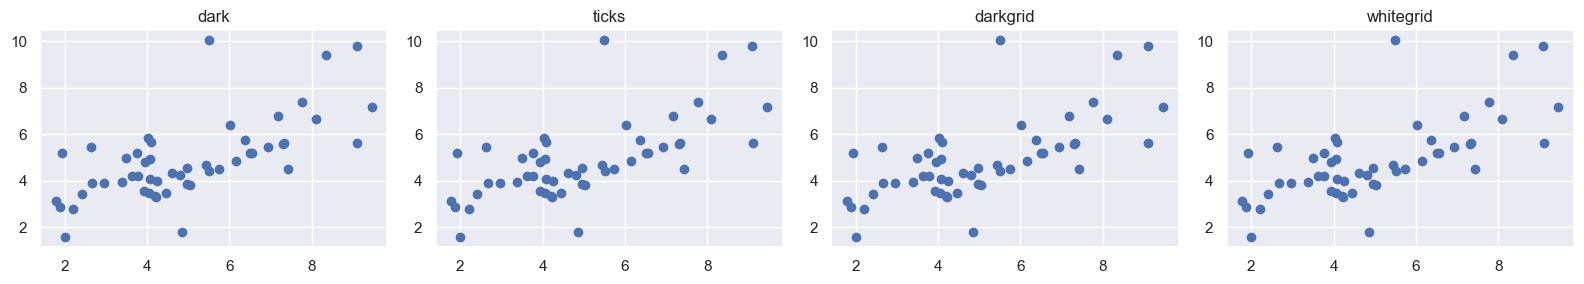

In [9]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3))
styles = ['dark', 'ticks', 'darkgrid', 'whitegrid']
for ax, style in zip(axes, styles):
    with sns.axes_style(style):
        fig2, a2 = plt.subplots()
        a2.scatter(df.speeding, df.alcohol)
        a2.set_title(style)
        plt.close(fig2)
    ax.scatter(df.speeding, df.alcohol)
    ax.set_title(style)
plt.tight_layout()
plt.show()

In [10]:
# Style parameters
param = sns.axes_style()
param

{'axes.facecolor': '#EAEAF2',
 'axes.edgecolor': 'white',
 'axes.grid': True,
 'axes.axisbelow': True,
 'axes.labelcolor': '.15',
 'figure.facecolor': 'white',
 'grid.color': 'white',
 'grid.linestyle': '-',
 'text.color': '.15',
 'xtick.color': '.15',
 'ytick.color': '.15',
 'xtick.direction': 'out',
 'ytick.direction': 'out',
 'lines.solid_capstyle': <CapStyle.round: 'round'>,
 'patch.edgecolor': 'w',
 'patch.force_edgecolor': True,
 'image.cmap': 'rocket',
 'font.family': ['sans-serif'],
 'font.sans-serif': ['Arial',
  'DejaVu Sans',
  'Liberation Sans',
  'Bitstream Vera Sans',
  'sans-serif'],
 'xtick.bottom': False,
 'xtick.top': False,
 'ytick.left': False,
 'ytick.right': False,
 'axes.spines.left': True,
 'axes.spines.bottom': True,
 'axes.spines.right': True,
 'axes.spines.top': True}

## 4. Tips Dataset — relplot

In [12]:
tips = sns.load_dataset('tips')
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


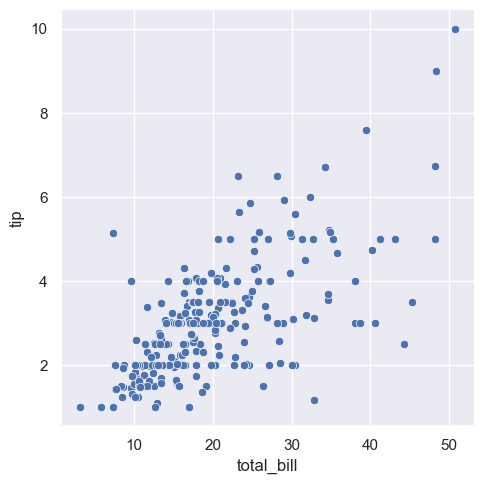

In [13]:
sns.relplot(data=tips, x='total_bill', y='tip')
plt.show()

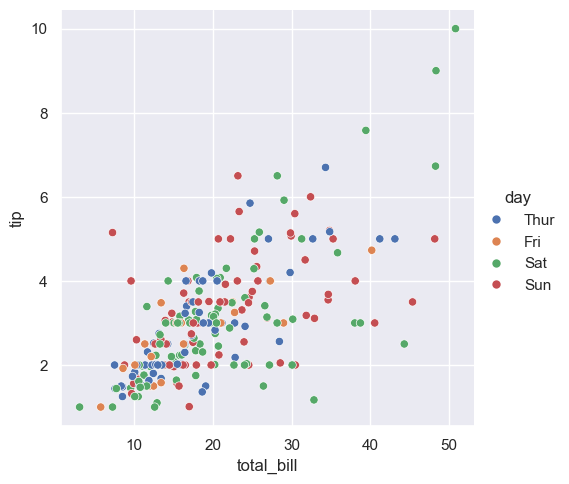

In [14]:
sns.relplot(data=tips, x='total_bill', y='tip', hue='day')
plt.show()

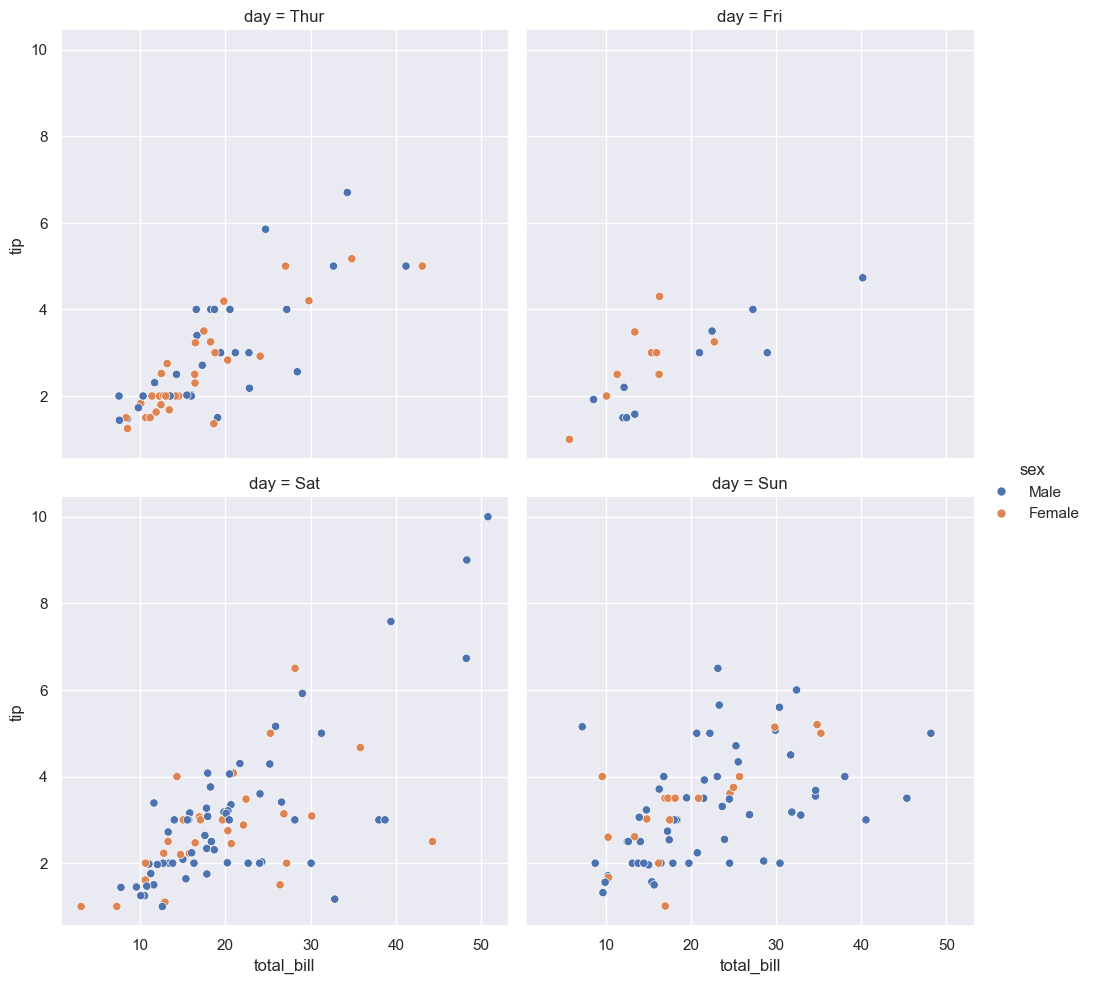

In [15]:
sns.relplot(data=tips, x='total_bill', y='tip', hue='sex', col='day', col_wrap=2)
plt.show()

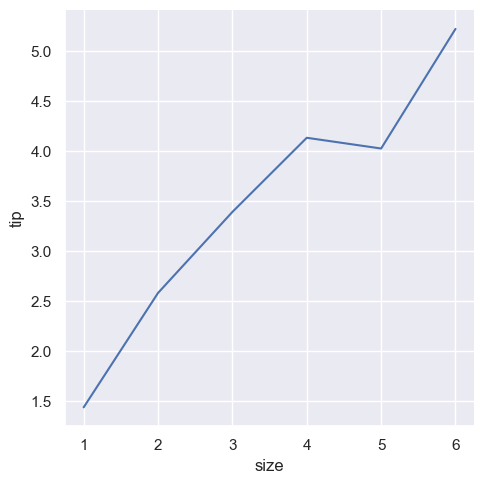

In [16]:
# FIX: ci=None is deprecated → use errorbar=None
sns.relplot(data=tips, x='size', y='tip', kind='line', errorbar=None)
plt.show()

## 5. Iris Dataset — Histogram
> **FIX:** `distplot` is removed in seaborn 0.12+ → replaced with `histplot`

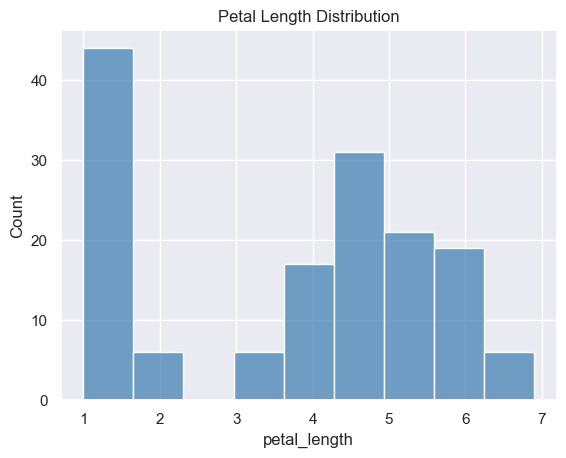

In [18]:
df_iris = sns.load_dataset('iris')
# FIX: sns.distplot() removed → use sns.histplot()
sns.histplot(df_iris['petal_length'], kde=False, color='steelblue')
plt.title('Petal Length Distribution')
plt.show()

## 6. Titanic Dataset — Bar, Count & Point Plots

In [20]:
sns.set_context('paper')
dt = sns.load_dataset('titanic')
dt.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


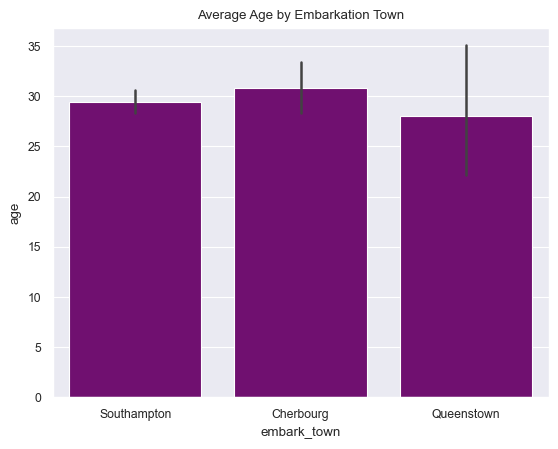

In [21]:
# Vertical bar plot
sns.barplot(x='embark_town', y='age', data=dt, color='purple')
plt.title('Average Age by Embarkation Town')
plt.show()

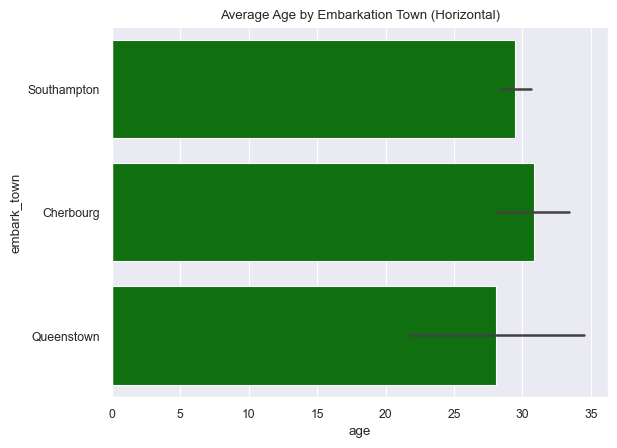

In [22]:
# Horizontal bar plot
sns.barplot(x='age', y='embark_town', data=dt, orient='h', color='green')
plt.title('Average Age by Embarkation Town (Horizontal)')
plt.show()

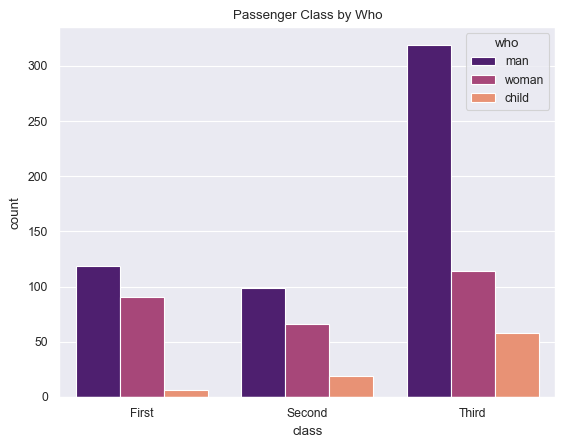

In [23]:
# Count plot
sns.countplot(x='class', hue='who', data=dt, palette='magma')
plt.title('Passenger Class by Who')
plt.show()

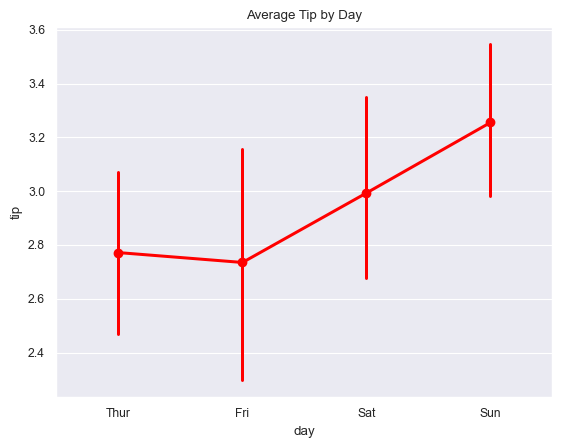

In [24]:
# Point plot
sns.pointplot(x='day', y='tip', data=tips, color='red')
plt.title('Average Tip by Day')
plt.show()

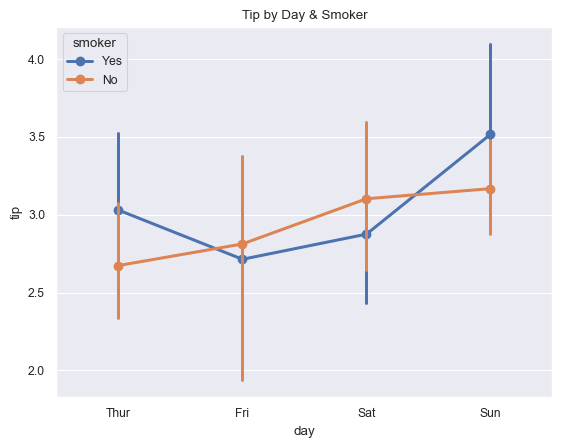

In [25]:
sns.pointplot(x='day', y='tip', data=tips, hue='smoker')
plt.title('Tip by Day & Smoker')
plt.show()

## 7. Joint Plot & Multi-plot Dashboard

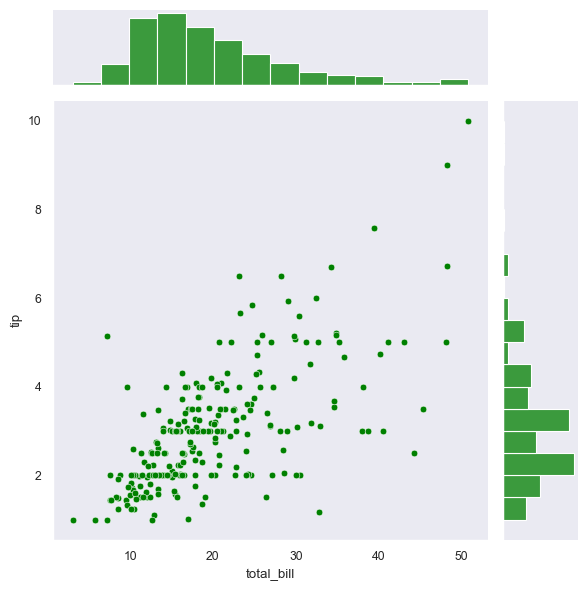

In [27]:
sns.set_style('dark')
sns.jointplot(x='total_bill', y='tip', data=tips, color='green')
plt.show()

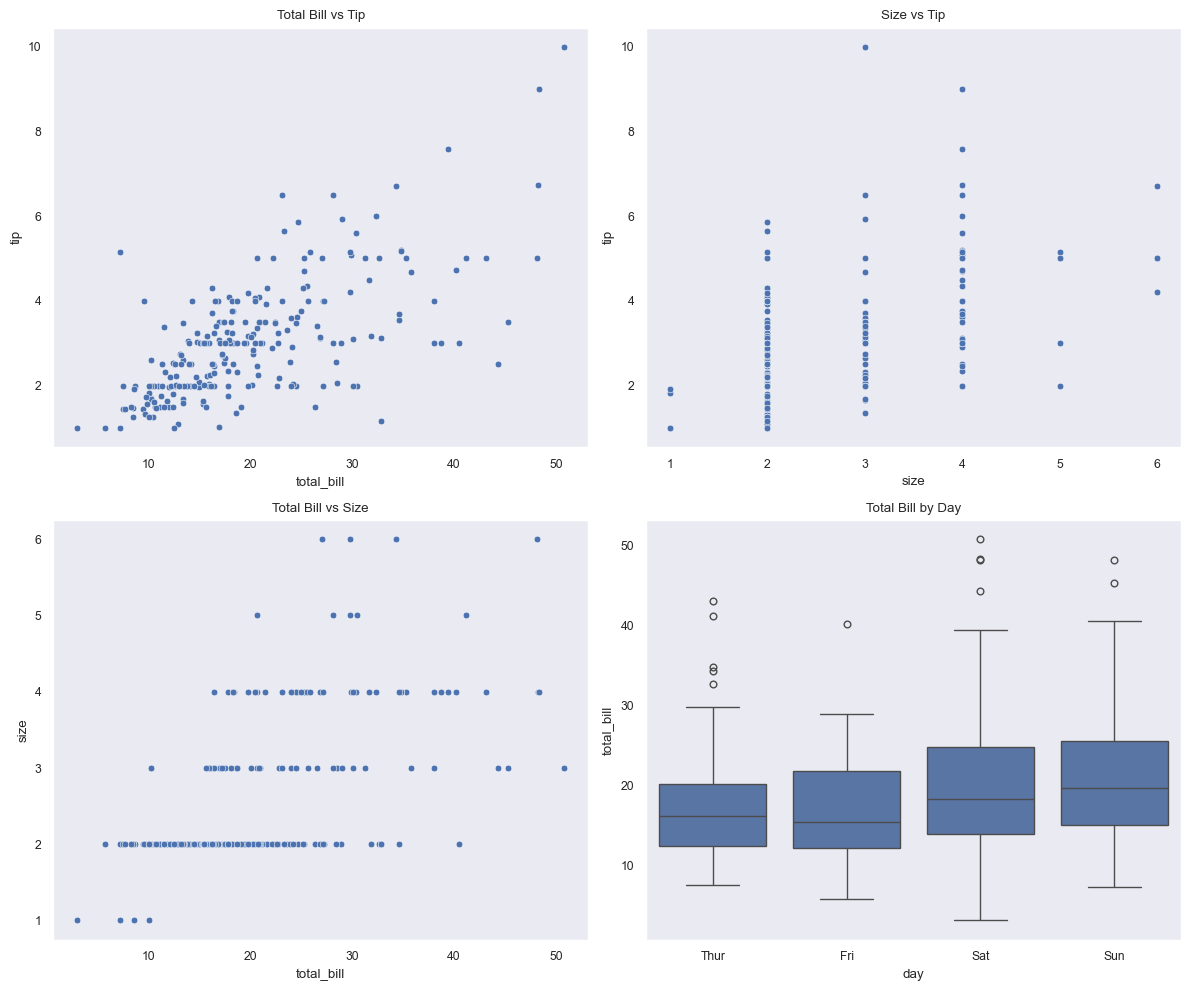

In [28]:
# Dashboard: 4 plots
sns.set_style('dark')
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

sns.scatterplot(x='total_bill', y='tip', data=tips, ax=axs[0,0])
axs[0,0].set_title('Total Bill vs Tip')

sns.scatterplot(x='size', y='tip', data=tips, ax=axs[0,1])
axs[0,1].set_title('Size vs Tip')

sns.scatterplot(x='total_bill', y='size', data=tips, ax=axs[1,0])
axs[1,0].set_title('Total Bill vs Size')

sns.boxplot(x='day', y='total_bill', data=tips, ax=axs[1,1])
axs[1,1].set_title('Total Bill by Day')

plt.tight_layout()
plt.show()